# Financial Data Analysis Mini Project

This project analyzes historical financial data across multiple asset classes:
- Stocks (SPY, IYW, VT)
- Bonds (TLT)
- Commodities (DBA, PDBC)
- Gold (IAU)

### Objective

- Analyze price trends over time  
- Study market behavior during COVID-19  
- Compute returns and volatility  
- Understand correlations between assets  
- Evaluate diversification benefits  

In [10]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

plt.style.use('ggplot')

## Data Collection

We fetch historical stock data using yfinance for multiple asset classes.

In [11]:
def get_stock_data(ticker, start, end):
    data = yf.download(ticker, start=start, end=end)

    if isinstance(data.columns, pd.MultiIndex):
        data.columns = data.columns.get_level_values(0)

    data.insert(0, 'Ticker', ticker)
    return data

## Data Preparation

- Combine multiple assets into a single dataframe  
- Align data by date  
- Use closing prices for analysis  

In [12]:
tickers = ['SPY', 'IYW', 'VT', 'DBA', 'TLT', 'PDBC', 'IAU']

df_list = []

for t in tickers:
    temp = get_stock_data(t, datetime(2020,1,1), datetime.today())
    temp = temp.reset_index()
    temp = temp.pivot(index='Date', columns='Ticker', values='Close')
    df_list.append(temp)

stock = pd.concat(df_list, axis=1)

stock.head()

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


Ticker,SPY,IYW,VT,DBA,TLT,PDBC,IAU
Date,,,,,,,
2020-01-02,296.888153,57.828777,72.245468,14.560220,114.166512,8.430121,29.219999
2020-01-03,294.640167,57.251518,71.591988,14.392556,115.924713,8.501049,29.620001
2020-01-06,295.764099,57.604694,71.856918,14.427855,115.266426,8.511179,29.920000
2020-01-07,294.932495,57.626614,71.636154,14.463152,114.699814,8.495982,30.040001
2020-01-08,296.504364,58.201443,71.927567,14.392556,113.941544,8.379460,29.820000


In [13]:
print(stock.shape)
print(stock.columns)

(1590, 7)
Index(['SPY', 'IYW', 'VT', 'DBA', 'TLT', 'PDBC', 'IAU'], dtype='str', name='Ticker')


### Dataset Overview

The dataset contains historical closing prices of multiple financial assets, including stocks, bonds, and commodities.

Each column represents a different asset, while the index represents time (Date).

This structured dataset allows us to compare performance across different asset classes.

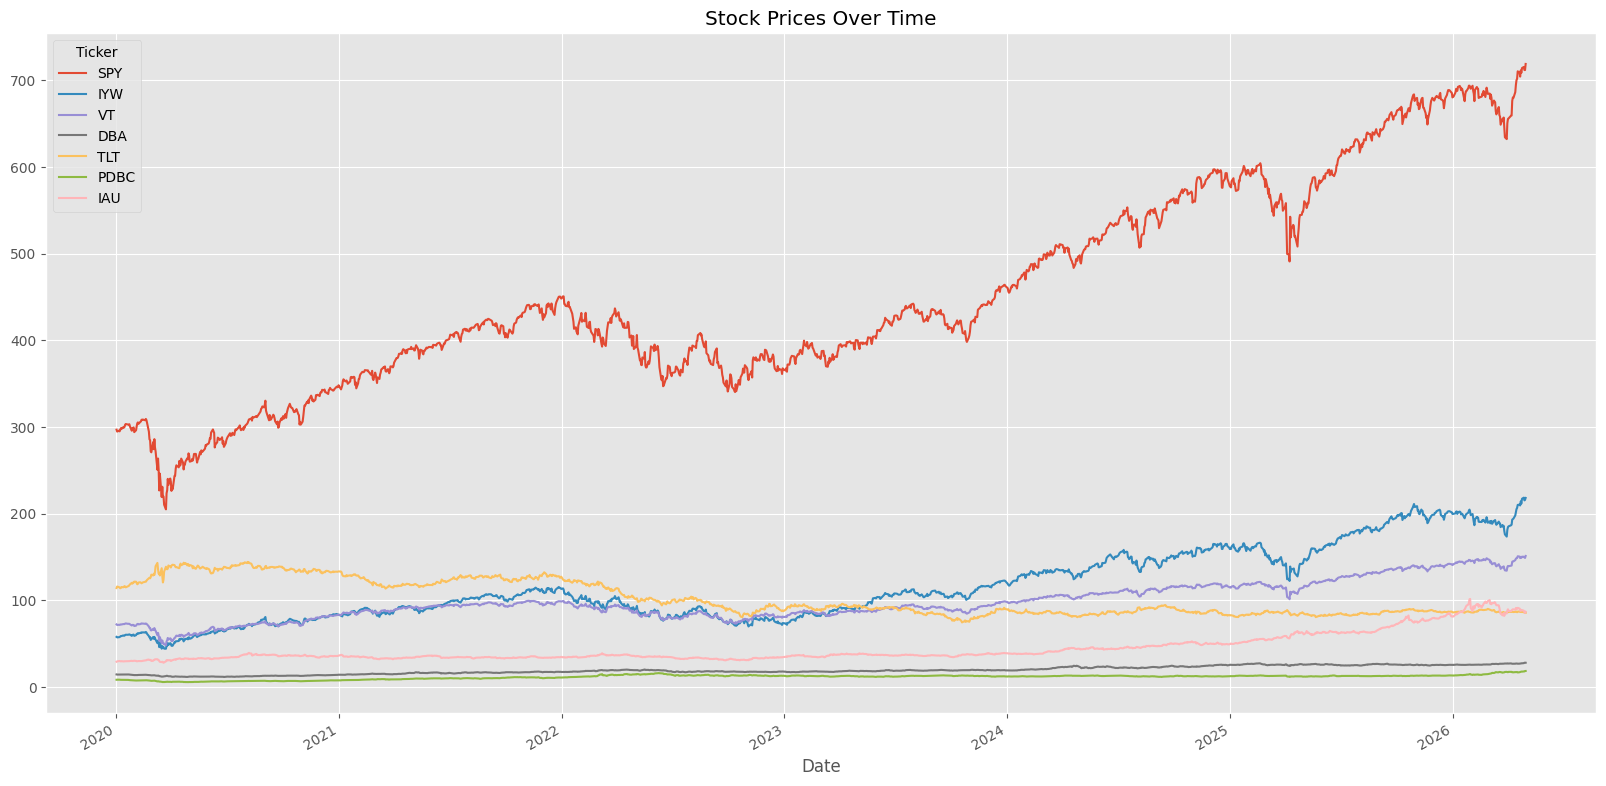

In [14]:
stock.plot(figsize=(20,10), title="Stock Prices Over Time")
plt.show()

## COVID-19 Market Impact Analysis

We analyze asset performance between Feb 2020 and July 2020.

Ticker
SPY      1.778729
IYW     17.001886
VT      -0.895649
DBA     -9.218955
TLT     18.280058
PDBC    -8.932171
IAU     25.232404
dtype: float64


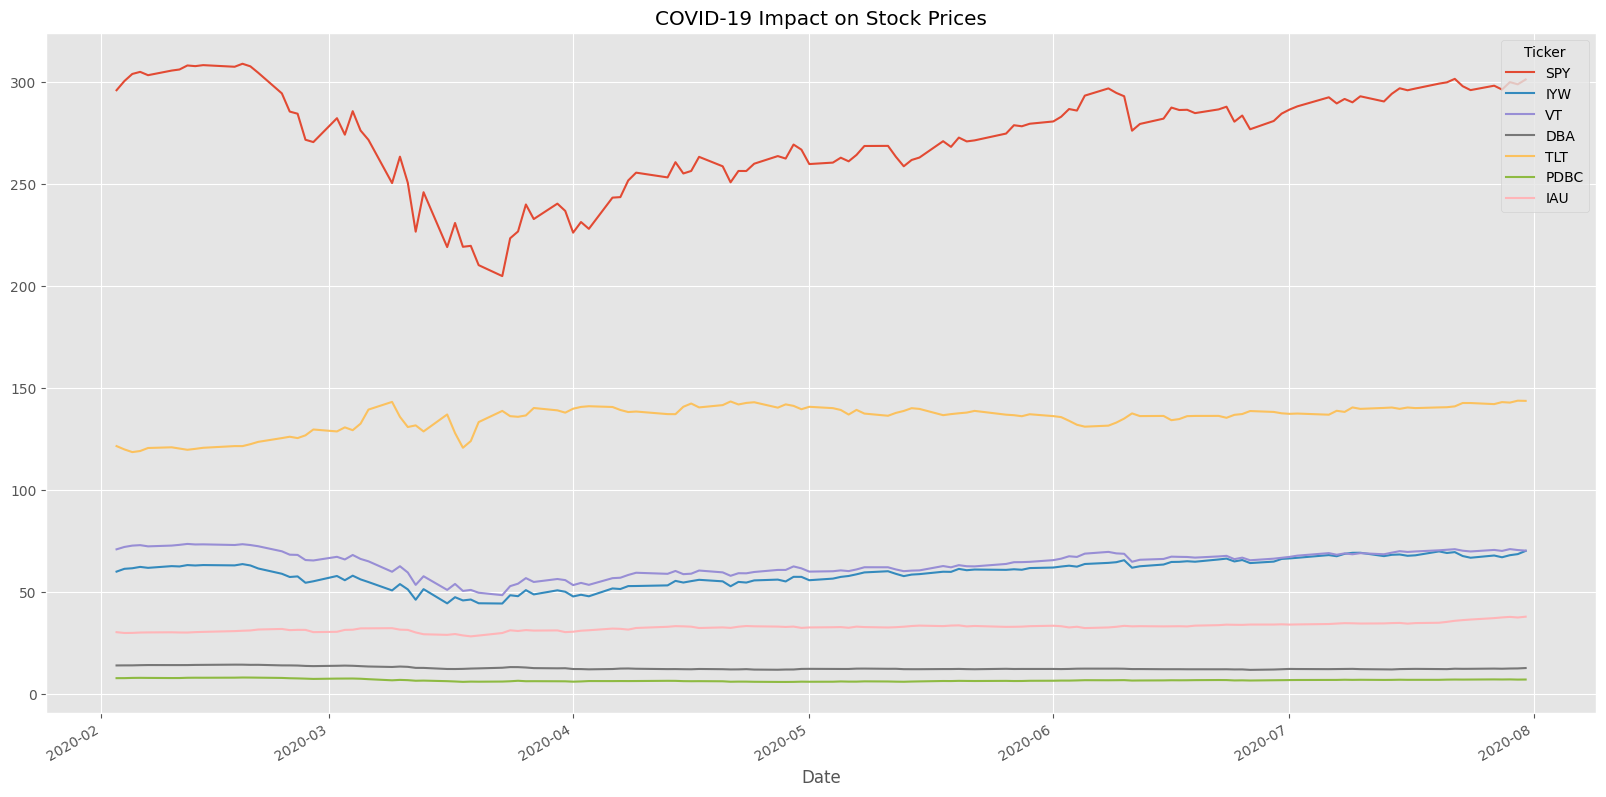

In [15]:
covid = stock['2020-2-1':'2020-7-31']

covid_pct = ((covid.iloc[-1] - covid.iloc[0]) / covid.iloc[0]) * 100
print(covid_pct)

covid.plot(figsize=(20,10), title="COVID-19 Impact on Stock Prices")
plt.show()

### Observations

- SPY showed limited recovery (~1.78%)
- Gold (IAU) increased significantly (~25.23%)
- Bonds (TLT) gained (~18.28%)

This shows that gold and bonds act as defensive assets during crises.

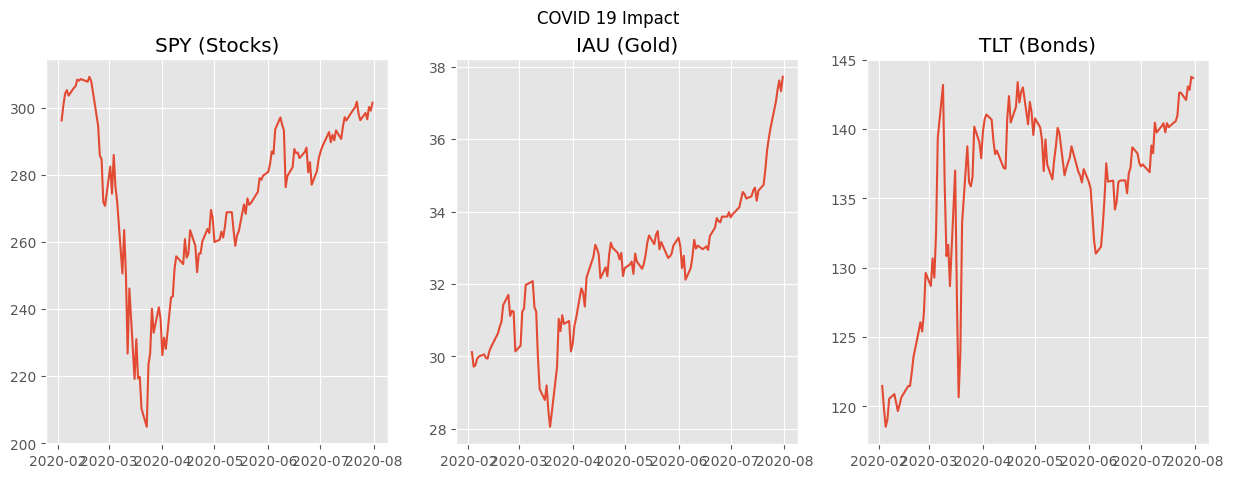

In [16]:
x = covid.index
s_y = covid['SPY']
i_y = covid['IAU']
t_y = covid['TLT']

fig, axs = plt.subplots(1, 3, figsize=(15, 5))

axs[0].plot(x, s_y)
axs[0].set_title("SPY (Stocks)")

axs[1].plot(x, i_y)
axs[1].set_title("IAU (Gold)")

axs[2].plot(x, t_y)
axs[2].set_title("TLT (Bonds)")

fig.suptitle("COVID 19 Impact")
plt.show()

The visualization shows that most assets follow an upward trend over time.  
However, during early 2020, a sharp decline is observed due to the COVID-19 pandemic.

Different assets respond differently:
- Stocks experienced a sharp fall
- Gold remained relatively stable
- Bonds showed defensive behavior

This highlights the importance of diversification in financial markets.

## Trading Volume Analysis

We analyze trading volume for PDBC to understand market activity.

[*********************100%***********************]  1 of 1 completed


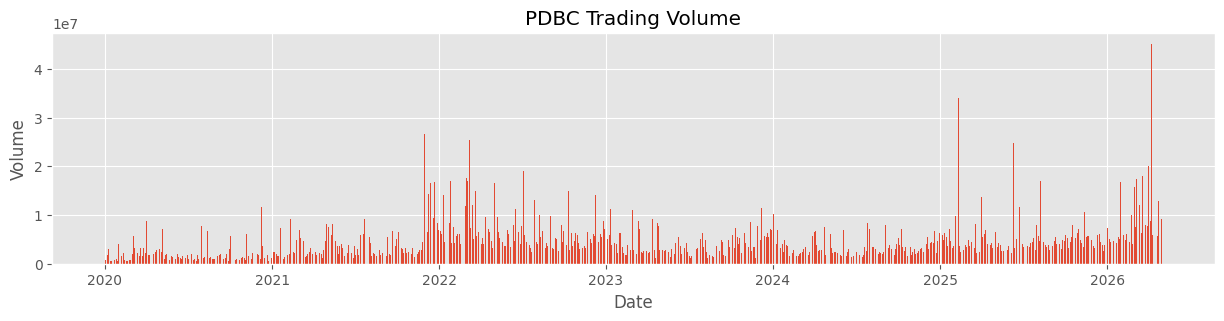

In [17]:
ticker = 'PDBC'
start = datetime(2020,1,1)
end = datetime.today()

df = get_stock_data(ticker, start, end)
df.head()

df = df[['Volume']]

x = df.index
y = df['Volume']

plt.figure(figsize=(15, 3))
plt.bar(x, y)
plt.title(f"{ticker} Trading Volume")
plt.xlabel("Date")
plt.ylabel("Volume")
plt.show()

## Price and Volume Comparison

[*********************100%***********************]  1 of 1 completed


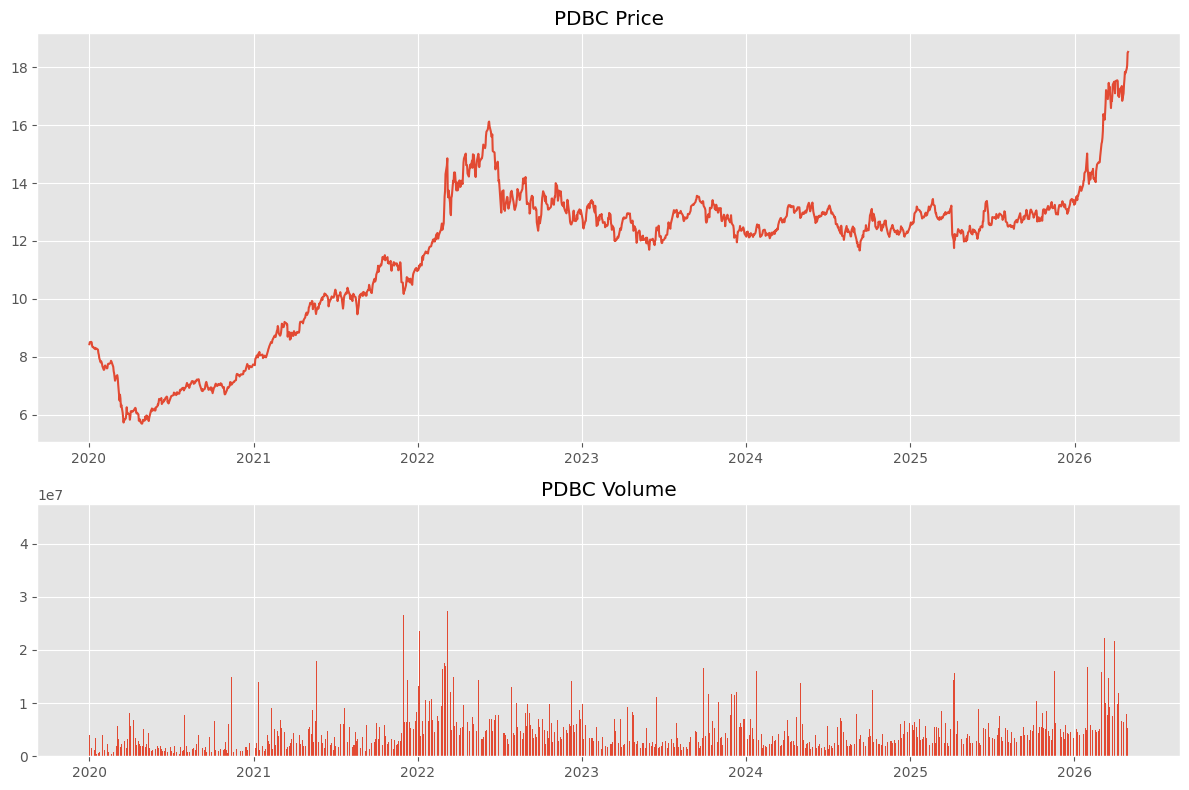

In [18]:
ticker = 'PDBC'
df = get_stock_data(ticker, start, end)

fig = plt.figure(figsize=(12, 8))

# Price (top)
ax1 = plt.subplot2grid((5,1), (0,0), rowspan=3)
ax1.plot(df.index, df['Close'])
ax1.set_title(f"{ticker} Price")

# Volume (bottom)
ax2 = plt.subplot2grid((5,1), (3,0), rowspan=2)
ax2.bar(df.index, df['Volume'])
ax2.set_title(f"{ticker} Volume")

plt.tight_layout()
plt.show()

Observation

Trading volume shows significant spikes during certain periods, especially during market uncertainty.

Higher volume indicates increased market participation, often triggered by major events or news.

This suggests that investor activity increases during volatile periods.

## Returns Analysis

Ticker
SPY     0.063931
IYW     0.099467
VT      0.054097
DBA     0.045170
TLT    -0.012504
PDBC    0.057131
IAU     0.074969
dtype: float64


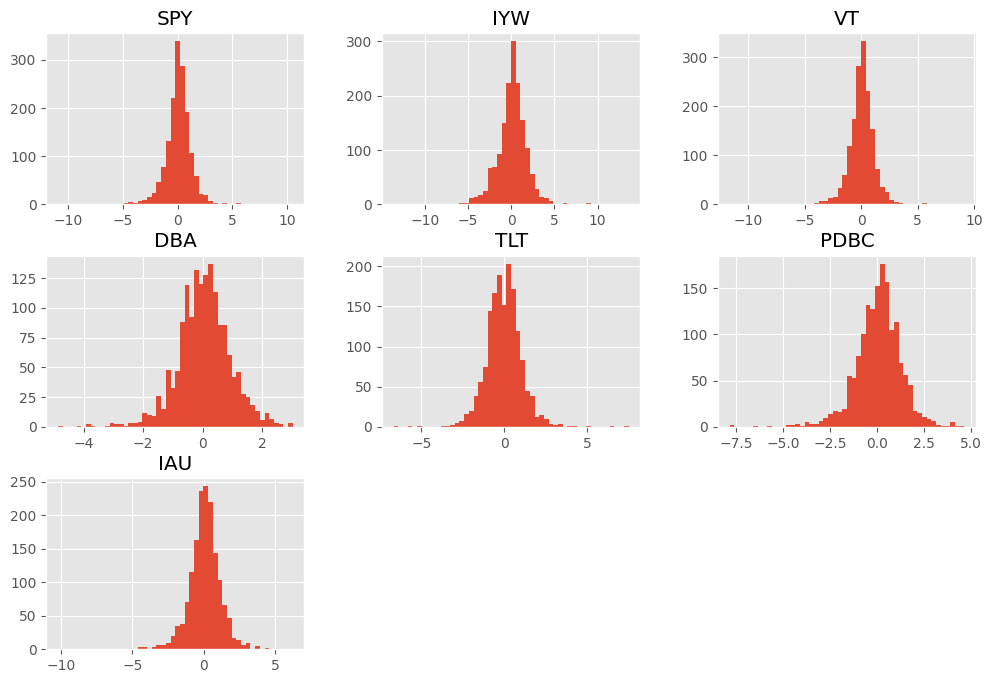

In [19]:
returns = stock.pct_change() * 100
returns = returns.fillna(0)

print(returns.mean())

returns.hist(bins=50, figsize=(12,8))
plt.show()

Average returns show that technology and stock indices provide higher returns, 
while bonds offer lower but more stable returns.

## Cumulative Returns

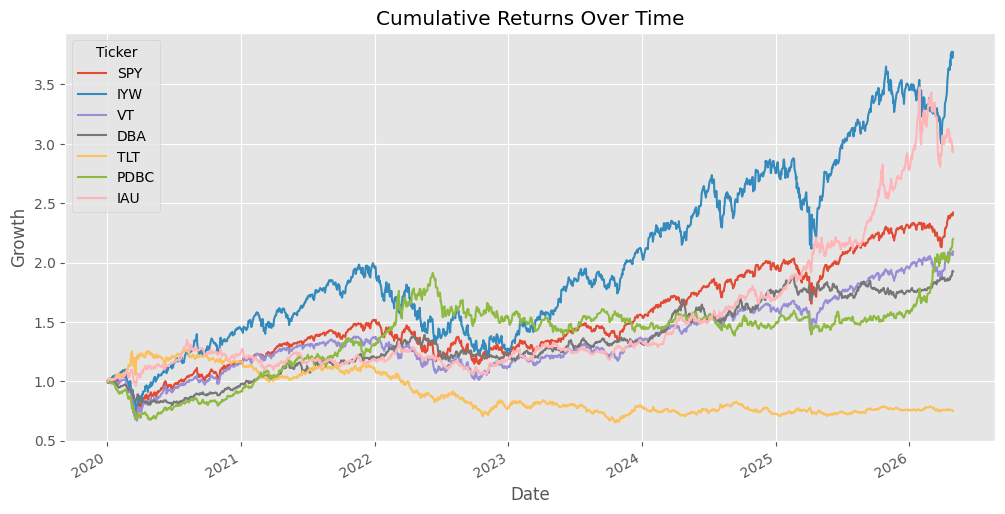

In [20]:
cum_returns = (1 + returns/100).cumprod()
cum_returns.head()

cum_returns.plot(figsize=(12,6), title="Cumulative Returns Over Time")
plt.xlabel("Date")
plt.ylabel("Growth")
plt.show()

Cumulative returns show how an investment grows over time.

SPY and IYW demonstrate strong long-term growth, while assets like bonds grow more steadily.

This highlights the trade-off between risk and return.

## Correlation Between Assets

Ticker       SPY       IYW        VT       DBA       TLT      PDBC       IAU
Ticker                                                                      
SPY     1.000000  0.920237  0.975200  0.227214 -0.114433  0.298261  0.135424
IYW     0.920237  1.000000  0.884557  0.191147 -0.070712  0.226250  0.138501
VT      0.975200  0.884557  1.000000  0.248178 -0.102306  0.322349  0.197694
DBA     0.227214  0.191147  0.248178  1.000000 -0.102503  0.461240  0.145217
TLT    -0.114433 -0.070712 -0.102306 -0.102503  1.000000 -0.153371  0.205889
PDBC    0.298261  0.226250  0.322349  0.461240 -0.153371  1.000000  0.306265
IAU     0.135424  0.138501  0.197694  0.145217  0.205889  0.306265  1.000000


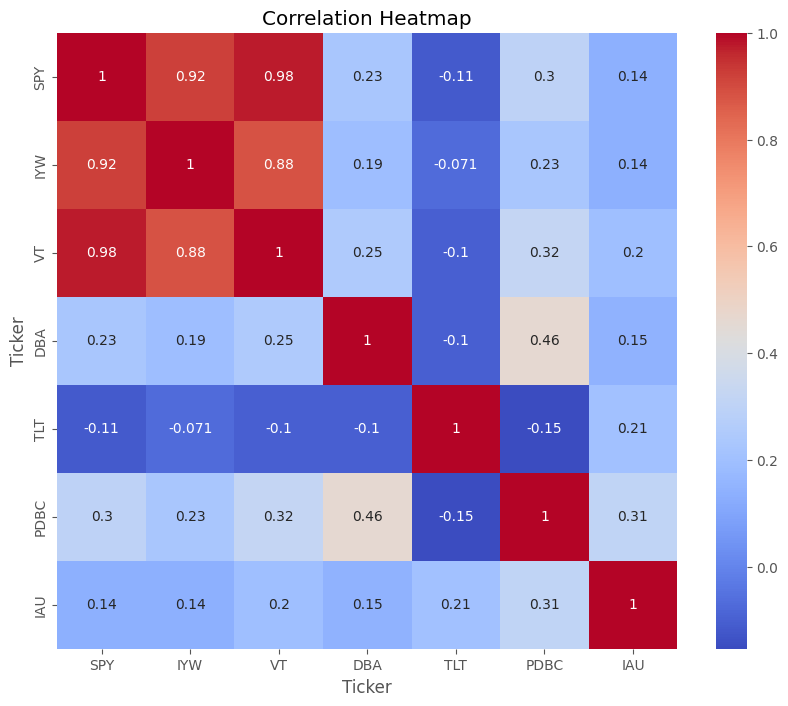

In [21]:
corr = returns.corr()
print(corr)

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

Strong positive correlation is observed between stock-based ETFs (SPY, IYW, VT).

Bonds (TLT) show weak or negative correlation with stocks, making them effective hedging assets.

Gold (IAU) shows low correlation, indicating diversification benefits.

## Volatility (Risk Analysis)

Ticker
IYW     1.785172
SPY     1.288216
VT      1.232603
PDBC    1.228503
IAU     1.131888
TLT     1.058232
DBA     0.890294
dtype: float64


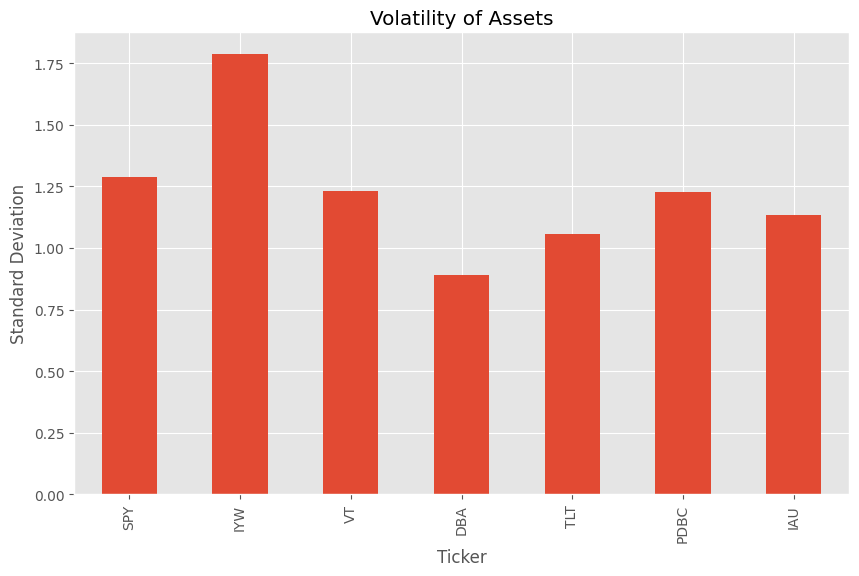

In [22]:
volatility = returns.std()
volatility

print(volatility.sort_values(ascending=False))

volatility.plot(kind='bar', figsize=(10,6), title="Volatility of Assets")
plt.ylabel("Standard Deviation")
plt.show()

**Insight**

Volatility measures the risk associated with each asset.

Assets with higher volatility experience larger price fluctuations, indicating higher risk.

Safer assets such as bonds tend to have lower volatility, while growth-oriented assets such as technology stocks exhibit higher volatility.

### Key Findings:
- Stocks provide higher returns but come with higher volatility
- Bonds act as a hedge during market downturns
- Gold remains relatively stable during crises
- Diversification across asset classes reduces overall portfolio risk

## Conclusion

This project demonstrates how financial data analysis can be used to understand asset behavior, risk, and relationships.

The analysis shows that:
- Different asset classes respond differently to economic conditions
- Diversification is essential to reduce portfolio risk
- Higher returns are typically associated with higher volatility

Overall, this project highlights the importance of combining multiple asset classes to build a balanced and resilient investment portfolio.